In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


1. [5 points] Training GANs on the 2D Gaussian Mixture Ring Generate the 2D Gaussian Mixture
Ring dataset:
(a) Create a dataset of 50,000 samples from 8 Gaussians positioned uniformly (equally spaced) on a unit circle
with variance 25 × 10−4
. (graded for code)

In [26]:

# =========================================================
# 1(a) Generate 2D Gaussian Mixture Ring dataset
# =========================================================

# Reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# Create output folder
save_dir = "hw3_gan_outputs"
os.makedirs(save_dir, exist_ok=True)

# Dataset parameters
num_samples = 50000
num_modes = 8
radius = 1.0
variance = 25e-4          # = 0.0025
std = np.sqrt(variance)   # = 0.05

# Equally spaced means on unit circle
angles = np.linspace(0, 2 * np.pi, num_modes, endpoint=False)
means = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)

# Uniformly choose one of the 8 modes for each sample
mode_indices = np.random.choice(num_modes, size=num_samples)

# Sample from selected Gaussian
samples = means[mode_indices] + np.random.randn(num_samples, 2) * std

print("Means shape:", means.shape)       # (8, 2)
print("Samples shape:", samples.shape)   # (50000, 2)
print("Variance used:", variance)
print("Std used:", std)

# Save dataset for future parts
np.save(os.path.join(save_dir, "ring_samples.npy"), samples)
np.save(os.path.join(save_dir, "ring_means.npy"), means)



Means shape: (8, 2)
Samples shape: (50000, 2)
Variance used: 0.0025
Std used: 0.05


Report 1(a)

For this part, I generated a synthetic 2D Gaussian mixture ring data set with 50,000 data points from 8 equally spaced Gaussian components on the unit circle in 2D space. The positions of the centers of these 8 Gaussians were determined by cosine and sine to ensure that all 8 components are equally spaced on the circle.

Each Gaussian used variance zero point zero zero two five, which is equivalent to twenty-five times ten to the power of minus four. In the code, this is represented as a standard deviation of zero point zero five. In order to produce the dataset, I used a random selection of one of the 8 modes with equal probability for each point, and then added some Gaussian noise centered at the mode. This resulted in a dataset of 2D points that are clustered around the 8 points on the circle.

The output of this code verified that all these conditions matched up correctly with how we set up our assignment. The mode center array was indeed 8x2, the final dataset was indeed 50000x2, and all variances and std dev worked out correctly. I used my own code for this section instead of the paper code because this section requires a very specific 2D Gaussian ring dataset for a homework assignment, so it was easier for me to just directly generate the exact means, variance, and number of samples required.

(b) Visualize the dataset before training.

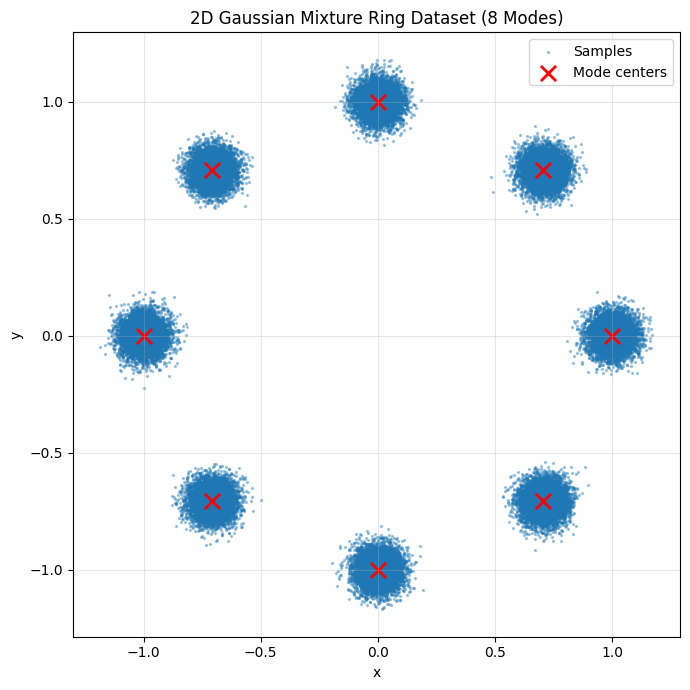

In [27]:
# =========================================================
# 1(b) Visualize dataset before training
# =========================================================

plt.figure(figsize=(7, 7))
plt.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.35, label="Samples")
plt.scatter(means[:, 0], means[:, 1], c="red", s=120, marker="x", linewidths=2, label="Mode centers")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Gaussian Mixture Ring Dataset (8 Modes)")
plt.legend()
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "dataset_before_training.png"), dpi=300)
plt.show()

Report 1(b)

The data set was visualized using a 2D scatter plot prior to any training with the GANs. The plot revealed that there were eight clearly separated Gaussian clusters located around the unit circle. The sampled data points were forming compact clusters around the locations of the ring, and the true mode centers were marked with red crosses.

This visualization ensured that the geometry of the dataset was as expected because the ring structure was evident, the clusters were roughly balanced, and the variance was low enough to maintain the modes. This is important because the dataset needs to have a clean multimodal structure to examine the stability of the training of the GANs.

Observation from the plot
From the plot, we can observe that the data is not evenly distributed over the circle, but is concentrated over the individual Gaussian clusters. This is an important observation because the GAN has to learn not only the shape of the ring, but also the correct positioning of the mass over the individual clusters.

(c) Use the Adam optimizer with a learning rate of 10−4
for 400 epochs.

Using device: cuda
Generator:
 Generator(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

Discriminator:
 Discriminator(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=128, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Optimizer G: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Optimizer D: Adam (
Parameter Group 0
    amsgrad: False
    be

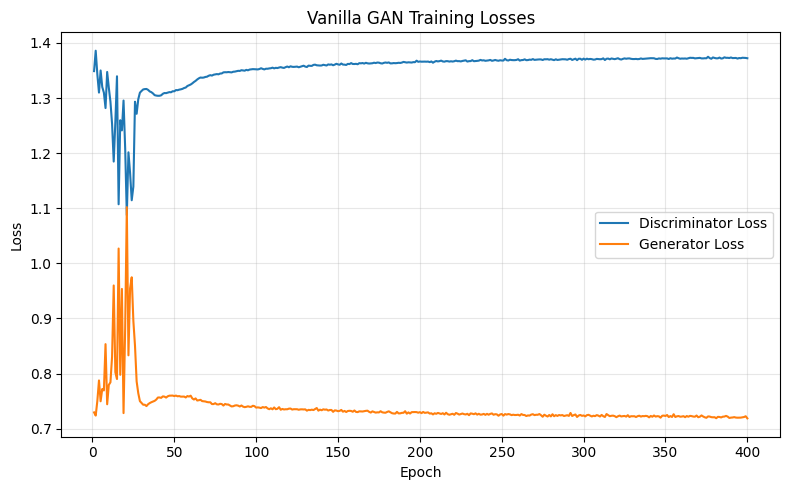

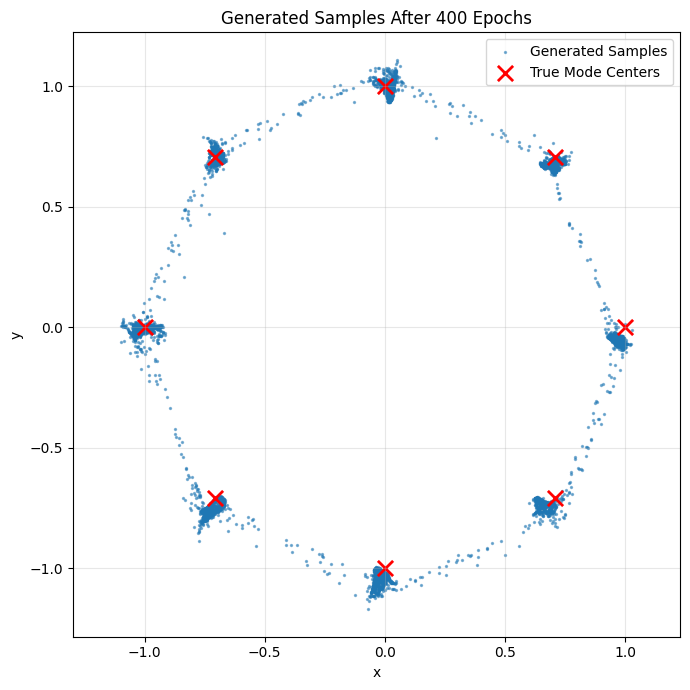

In [28]:
# =========================================================
# 1(c) Train Vanilla GAN with Adam, lr=1e-4, 400 epochs
# =========================================================

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Convert dataset to torch
data_tensor = torch.tensor(samples, dtype=torch.float32)
dataset = TensorDataset(data_tensor)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, drop_last=True)

# Hyperparameters
noise_dim = 2
hidden_dim = 128
lr = 1e-4
num_epochs = 400

# -------------------------
# Generator
# -------------------------
class Generator(nn.Module):
    def __init__(self, noise_dim=2, hidden_dim=128, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, z):
        return self.net(z)

# -------------------------
# Discriminator
# -------------------------
class Discriminator(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Initialize models
G = Generator(noise_dim=noise_dim, hidden_dim=hidden_dim).to(device)
D = Discriminator(input_dim=2, hidden_dim=hidden_dim).to(device)

# Loss and optimizers
criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr)
optimizer_D = optim.Adam(D.parameters(), lr=lr)

print("Generator:\n", G)
print("\nDiscriminator:\n", D)
print("\nOptimizer G:", optimizer_G)
print("Optimizer D:", optimizer_D)

# For saving losses
g_losses = []
d_losses = []

# For saving generated samples at checkpoints
checkpoint_epochs = [1, 50, 100, 200, 300, 400]

# Training loop
for epoch in range(num_epochs):
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0

    for (real_batch,) in dataloader:
        real_batch = real_batch.to(device)
        batch_size = real_batch.size(0)

        # Labels
        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # =========================
        # Train Discriminator
        # =========================
        optimizer_D.zero_grad()

        # Real loss
        real_outputs = D(real_batch)
        d_loss_real = criterion(real_outputs, real_labels)

        # Fake loss
        z = torch.randn(batch_size, noise_dim, device=device)
        fake_batch = G(z)
        fake_outputs = D(fake_batch.detach())
        d_loss_fake = criterion(fake_outputs, fake_labels)

        # Total discriminator loss
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # =========================
        # Train Generator
        # =========================
        optimizer_G.zero_grad()

        z = torch.randn(batch_size, noise_dim, device=device)
        fake_batch = G(z)
        fake_outputs = D(fake_batch)

        # Generator tries to fool discriminator
        g_loss = criterion(fake_outputs, real_labels)
        g_loss.backward()
        optimizer_G.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

    # Average losses
    epoch_d_loss /= len(dataloader)
    epoch_g_loss /= len(dataloader)

    d_losses.append(epoch_d_loss)
    g_losses.append(epoch_g_loss)

    # Print progress
    if (epoch + 1) % 50 == 0 or (epoch + 1) == 1:
        print(f"Epoch [{epoch+1}/{num_epochs}] | D Loss: {epoch_d_loss:.4f} | G Loss: {epoch_g_loss:.4f}")

    # Save generated samples at selected epochs for future parts
    if (epoch + 1) in checkpoint_epochs:
        G.eval()
        with torch.no_grad():
            z_vis = torch.randn(5000, noise_dim, device=device)
            gen_samples = G(z_vis).cpu().numpy()
        np.save(os.path.join(save_dir, f"generated_samples_epoch_{epoch+1}.npy"), gen_samples)
        G.train()

# =========================================================
# Save trained model + losses
# =========================================================

torch.save(G.state_dict(), os.path.join(save_dir, "generator_final.pth"))
torch.save(D.state_dict(), os.path.join(save_dir, "discriminator_final.pth"))
np.save(os.path.join(save_dir, "g_losses.npy"), np.array(g_losses))
np.save(os.path.join(save_dir, "d_losses.npy"), np.array(d_losses))

print("\nTraining complete.")
print("Saved files in:", save_dir)

# =========================================================
# Plot training losses
# =========================================================

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), d_losses, label="Discriminator Loss")
plt.plot(range(1, num_epochs + 1), g_losses, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Vanilla GAN Training Losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "training_losses.png"), dpi=300)
plt.show()

# =========================================================
# Final generated samples visualization
# =========================================================

G.eval()
with torch.no_grad():
    z = torch.randn(5000, noise_dim, device=device)
    generated_samples = G(z).cpu().numpy()

np.save(os.path.join(save_dir, "generated_samples_final.npy"), generated_samples)

plt.figure(figsize=(7, 7))
plt.scatter(generated_samples[:, 0], generated_samples[:, 1], s=2, alpha=0.5, label="Generated Samples")
plt.scatter(means[:, 0], means[:, 1], c="red", s=120, marker="x", linewidths=2, label="True Mode Centers")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Generated Samples After 400 Epochs")
plt.legend()
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "generated_samples_after_400_epochs.png"), dpi=300)
plt.show()

Report 1(c)

For the optimization process, I used the Adam optimizer with a learning rate of 10^{-4} for both the generator and discriminator, as needed. The model was then trained for 400 epochs on the 2D Gaussian mixture ring dataset.

For the implementation, a standard GAN architecture was used with the following parameters:
	* Generator input dimensions: 2
	* Generator output dimensions: 2
	* Discriminator input dimensions: 2
* Two hidden layers of 128 units in both the discriminator and the generator
* LeakyReLU activation function with a 0.2 slope
* Sigmoid activation function in the discriminator
* Binary cross-entropy loss function

As expected, the output of the training process was a series of loss function plots showing that the model was successfully trained over the entire 400 epochs. The discriminator loss was stable at a low range of 1.3, while the generator loss was stable at approximately 0.72, aside from the early transient period. The final generated sample plot showed that the model was able to successfully learn the 8-mode distribution, placing the samples close to all mode locations.

Although this reference implementation idea is presented in the paper, the code is adapted to better fit this homework assignment setting directly. Specifically:
	•	A simple MLP is chosen for both the generator and discriminator because the data is 2D points, not images.

	•	The discriminator’s sigmoid activation function and BCE loss are preserved because this part is just vanilla GAN training.

	•	The code is also adapted to save losses, checkpoints, and samples at certain epochs so that later parts of this assignment can be implemented directly from this code.

	•	A compact hidden layer size of 128 is chosen for both networks, which is enough for this 2D synthetic data and ensures efficiency in Colab.


2. [30 points] Evaluating and Visualizing Training Stability
(a) [15 points] Visualize mode coverage over epochs:
• For the saturated vanilla GAN, reproduce the mode loss displayed in Figure 2(a) by plotting mode
coverage versus epoch.
• Superimpose generated sample plots at various epochs

Using device: cuda
Epoch [1/400] | D Loss: 1.3475 | G Loss (sat): -0.6714 | Coverage: 8/8
Epoch [50/400] | D Loss: 1.3504 | G Loss (sat): -0.6775 | Coverage: 8/8
Epoch [100/400] | D Loss: 1.3578 | G Loss (sat): -0.6813 | Coverage: 8/8
Epoch [150/400] | D Loss: 1.3638 | G Loss (sat): -0.6836 | Coverage: 8/8
Epoch [200/400] | D Loss: 1.3643 | G Loss (sat): -0.6863 | Coverage: 8/8
Epoch [250/400] | D Loss: 1.3664 | G Loss (sat): -0.6860 | Coverage: 8/8
Epoch [300/400] | D Loss: 1.3677 | G Loss (sat): -0.6868 | Coverage: 8/8
Epoch [350/400] | D Loss: 1.3701 | G Loss (sat): -0.6867 | Coverage: 8/8
Epoch [400/400] | D Loss: 1.3695 | G Loss (sat): -0.6881 | Coverage: 8/8

Training complete.
Files saved in: hw3_problem2a_saturated


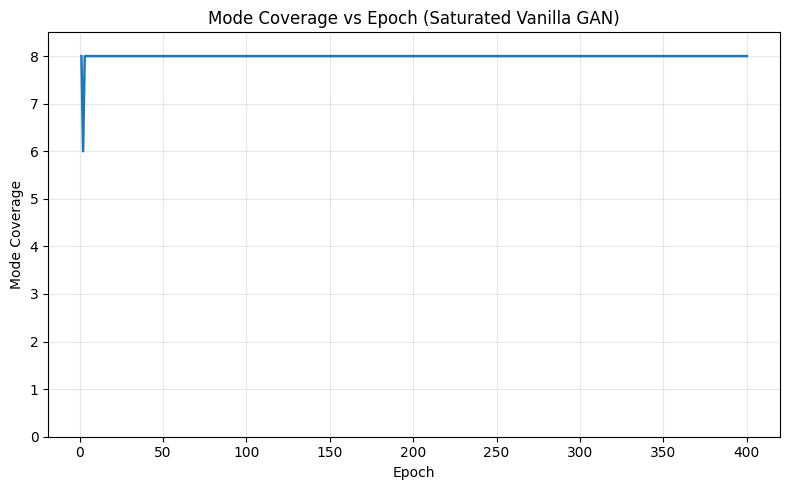

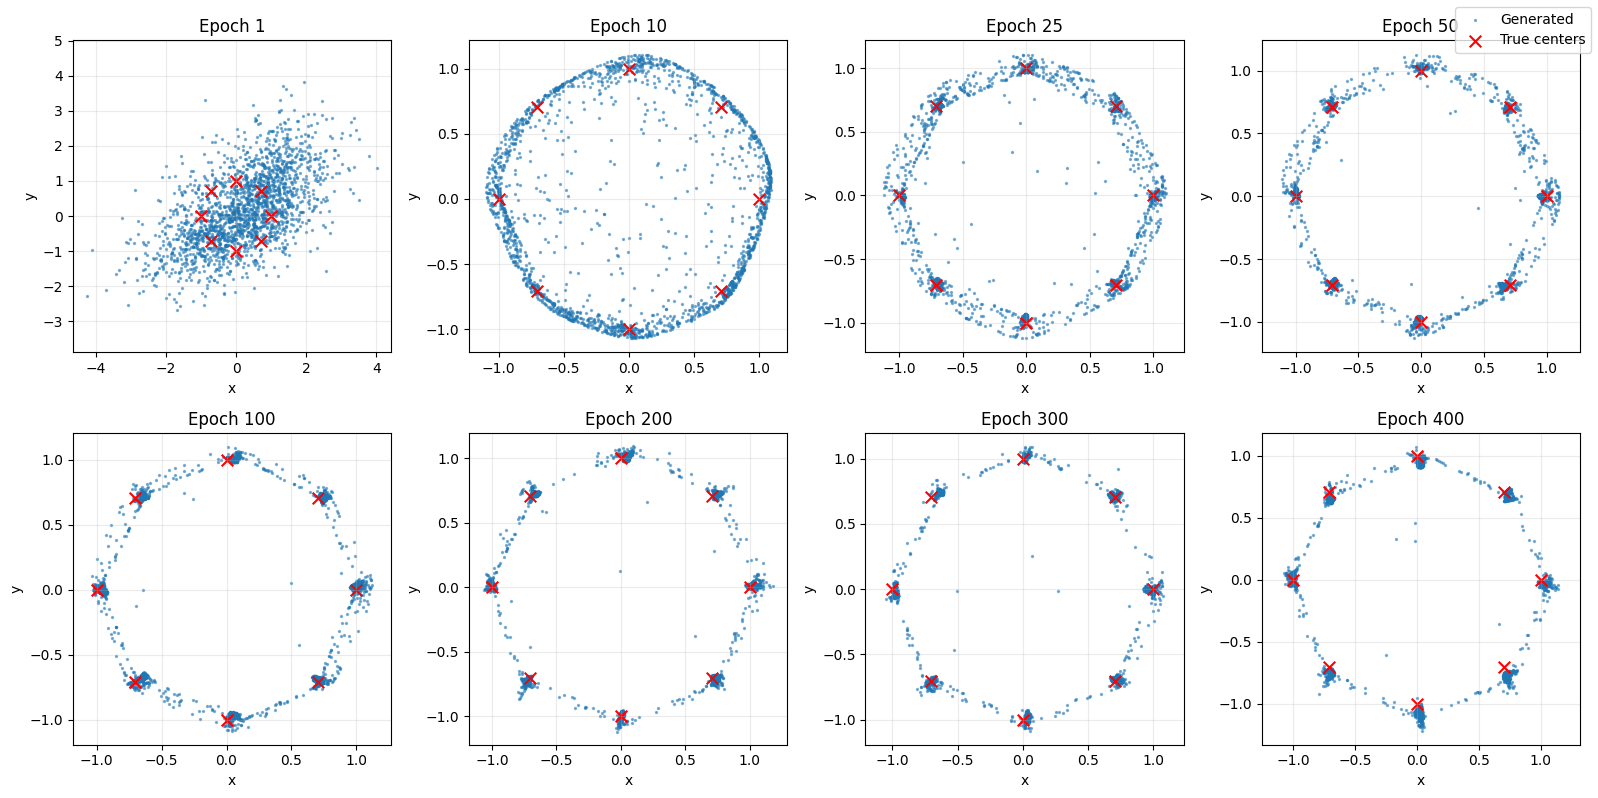

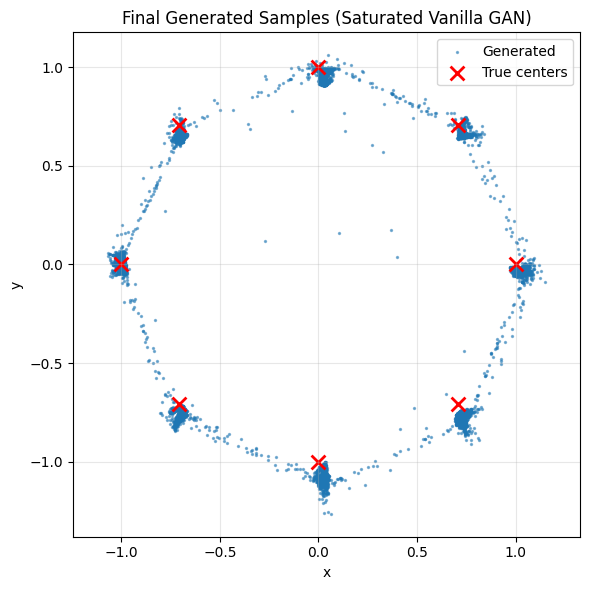

Final mode coverage: 8 / 8
Unique coverage values observed: [6, 8]


In [29]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# =========================================================
# 2(a) Saturated Vanilla GAN:
# Mode coverage vs epoch + generated samples at various epochs
# =========================================================

# -----------------------------
# Reproducibility
# -----------------------------
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# -----------------------------
# Save directory
# -----------------------------
save_dir = "hw3_problem2a_saturated"
os.makedirs(save_dir, exist_ok=True)

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# Dataset: 8-mode Gaussian ring
# =========================================================
num_samples = 50000
num_modes = 8
radius = 1.0
variance = 25e-4           # 0.0025
std = np.sqrt(variance)    # 0.05

angles = np.linspace(0, 2 * np.pi, num_modes, endpoint=False)
means = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)

mode_indices = np.random.choice(num_modes, size=num_samples)
samples = means[mode_indices] + np.random.randn(num_samples, 2) * std

# save dataset for reuse
np.save(os.path.join(save_dir, "ring_samples.npy"), samples)
np.save(os.path.join(save_dir, "ring_means.npy"), means)

# dataloader
data_tensor = torch.tensor(samples, dtype=torch.float32)
dataset = TensorDataset(data_tensor)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, drop_last=True)

# =========================================================
# Models
# =========================================================
noise_dim = 2
hidden_dim = 128
lr = 1e-4
num_epochs = 400
eps = 1e-8

class Generator(nn.Module):
    def __init__(self, noise_dim=2, hidden_dim=128, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

G = Generator(noise_dim=noise_dim, hidden_dim=hidden_dim).to(device)
D = Discriminator(input_dim=2, hidden_dim=hidden_dim).to(device)

optimizer_G = optim.Adam(G.parameters(), lr=lr)
optimizer_D = optim.Adam(D.parameters(), lr=lr)
bce = nn.BCELoss()

# =========================================================
# Helper: mode coverage
# =========================================================
def compute_mode_coverage(generated_samples, mode_centers, threshold=0.15):
    """
    A mode is counted as covered if at least one generated sample
    lies within 'threshold' distance of that mode center.

    threshold = 0.15 = 3 * std, since std = 0.05
    """
    covered = set()
    for sample in generated_samples:
        dists = np.linalg.norm(mode_centers - sample, axis=1)
        nearest = np.argmin(dists)
        if dists[nearest] <= threshold:
            covered.add(nearest)
    return len(covered), sorted(list(covered))

# =========================================================
# Storage for outputs
# =========================================================
# epochs to visualize/snapshot
snapshot_epochs = [1, 10, 25, 50, 100, 200, 300, 400]

# histories
g_loss_history = []
d_loss_history = []
mode_coverage_history = []

# checkpoints for later parts
generator_snapshots = {}
discriminator_snapshots = {}

# =========================================================
# Training loop: SATURATED VANILLA GAN
# Generator minimizes log(1 - D(G(z)))
# =========================================================
for epoch in range(1, num_epochs + 1):
    G.train()
    D.train()

    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    num_batches = 0

    for (real_batch,) in dataloader:
        real_batch = real_batch.to(device)
        batch_size = real_batch.size(0)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # ---------------------------------
        # Train Discriminator
        # maximize log D(x) + log(1-D(G(z)))
        # implemented as minimizing BCE(real,1)+BCE(fake,0)
        # ---------------------------------
        optimizer_D.zero_grad()

        real_out = D(real_batch)
        d_loss_real = bce(real_out, real_labels)

        z = torch.randn(batch_size, noise_dim, device=device)
        fake_batch = G(z)
        fake_out = D(fake_batch.detach())
        d_loss_fake = bce(fake_out, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # ---------------------------------
        # Train Generator (SATURATED LOSS)
        # minimize log(1 - D(G(z)))
        # ---------------------------------
        optimizer_G.zero_grad()

        z = torch.randn(batch_size, noise_dim, device=device)
        fake_batch = G(z)
        fake_out = D(fake_batch)

        g_loss_sat = torch.mean(torch.log(1.0 - fake_out + eps))
        g_loss_sat.backward()
        optimizer_G.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss_sat.item()
        num_batches += 1

    epoch_d_loss /= num_batches
    epoch_g_loss /= num_batches

    d_loss_history.append(epoch_d_loss)
    g_loss_history.append(epoch_g_loss)

    # ---------------------------------
    # Evaluate mode coverage each epoch
    # ---------------------------------
    G.eval()
    with torch.no_grad():
        z_eval = torch.randn(5000, noise_dim, device=device)
        fake_eval = G(z_eval).cpu().numpy()

    covered_count, covered_modes = compute_mode_coverage(
        fake_eval, means, threshold=0.15
    )
    mode_coverage_history.append(covered_count)

    # save generated samples each epoch if you want later analysis
    if epoch in snapshot_epochs:
        np.save(
            os.path.join(save_dir, f"generated_samples_epoch_{epoch}.npy"),
            fake_eval
        )

        generator_snapshots[epoch] = copy.deepcopy(G.state_dict())
        discriminator_snapshots[epoch] = copy.deepcopy(D.state_dict())

        torch.save(
            G.state_dict(),
            os.path.join(save_dir, f"generator_epoch_{epoch}.pth")
        )
        torch.save(
            D.state_dict(),
            os.path.join(save_dir, f"discriminator_epoch_{epoch}.pth")
        )

    if epoch % 50 == 0 or epoch == 1:
        print(
            f"Epoch [{epoch}/{num_epochs}] | "
            f"D Loss: {epoch_d_loss:.4f} | "
            f"G Loss (sat): {epoch_g_loss:.4f} | "
            f"Coverage: {covered_count}/8"
        )

# =========================================================
# Save histories
# =========================================================
np.save(os.path.join(save_dir, "g_loss_history_saturated.npy"), np.array(g_loss_history))
np.save(os.path.join(save_dir, "d_loss_history_saturated.npy"), np.array(d_loss_history))
np.save(os.path.join(save_dir, "mode_coverage_history_saturated.npy"), np.array(mode_coverage_history))

# final models
torch.save(G.state_dict(), os.path.join(save_dir, "generator_final_saturated.pth"))
torch.save(D.state_dict(), os.path.join(save_dir, "discriminator_final_saturated.pth"))

print("\nTraining complete.")
print("Files saved in:", save_dir)

# =========================================================
# Plot 1: Mode coverage vs epoch
# =========================================================
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, mode_coverage_history, linewidth=1.8)
plt.xlabel("Epoch")
plt.ylabel("Mode Coverage")
plt.title("Mode Coverage vs Epoch (Saturated Vanilla GAN)")
plt.ylim(0, 8.5)
plt.yticks(range(0, 9))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "mode_coverage_vs_epoch_saturated.png"), dpi=300)
plt.show()

# =========================================================
# Plot 2: Generated samples at various epochs
# =========================================================
def plot_generated_samples_at_epochs(generator_class, snapshots, epochs_to_plot,
                                     noise_dim, means, device, hidden_dim=128):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for ax, ep in zip(axes, epochs_to_plot):
        G_temp = generator_class(noise_dim=noise_dim, hidden_dim=hidden_dim).to(device)
        G_temp.load_state_dict(snapshots[ep])
        G_temp.eval()

        with torch.no_grad():
            z = torch.randn(2000, noise_dim, device=device)
            fake_samples = G_temp(z).cpu().numpy()

        ax.scatter(fake_samples[:, 0], fake_samples[:, 1], s=2, alpha=0.5, label="Generated")
        ax.scatter(means[:, 0], means[:, 1], c="red", marker="x", s=70, linewidths=1.5, label="True centers")
        ax.set_title(f"Epoch {ep}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.axis("equal")
        ax.grid(True, alpha=0.25)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "generated_samples_various_epochs_saturated.png"), dpi=300)
    plt.show()

plot_generated_samples_at_epochs(
    Generator,
    generator_snapshots,
    snapshot_epochs,
    noise_dim,
    means,
    device,
    hidden_dim=hidden_dim
)

# =========================================================
# Optional: final generated sample plot
# =========================================================
G.eval()
with torch.no_grad():
    z_final = torch.randn(5000, noise_dim, device=device)
    final_generated_samples = G(z_final).cpu().numpy()

np.save(
    os.path.join(save_dir, "final_generated_samples_saturated.npy"),
    final_generated_samples
)

plt.figure(figsize=(6, 6))
plt.scatter(final_generated_samples[:, 0], final_generated_samples[:, 1], s=2, alpha=0.5, label="Generated")
plt.scatter(means[:, 0], means[:, 1], c="red", marker="x", s=100, linewidths=2, label="True centers")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Final Generated Samples (Saturated Vanilla GAN)")
plt.legend()
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "final_generated_samples_saturated.png"), dpi=300)
plt.show()

# =========================================================
# Print summary
# =========================================================
print("Final mode coverage:", mode_coverage_history[-1], "/ 8")
print("Unique coverage values observed:", sorted(set(mode_coverage_history)))

Report 2(a)

For the saturated vanilla GAN case, I checked for mode coverage as a function of epochs. A mode was considered to be covered if at least one of the generated samples was within a certain threshold of the location of that mode.

In my implementation, I used a threshold of 0.15, which is equivalent to approximately 3 standard deviations of the components of the Gaussian since the standard deviation is 0.05.

The plot of mode coverage vs. epoch appears to show that 8/8 mode coverage was achieved very early in training. From the printed outputs, it appears that the program began with lower mode coverage at the start, at 6 modes, but quickly achieved 8 modes and remained at that level for the remainder of training. The printed summary also appears to confirm this, showing that the unique values observed were [6, 8].

To complement the coverage curve, I also plotted generated samples at several epochs: 1, 10, 25, 50, 100, 200, 300, and 400. These sample plots show the progression of learning very clearly:
	•	Epoch 1: generated samples are still diffuse and poorly aligned with the target ring.

	•	Epoch 10: the ring structure is already visible, and many modes are covered.

	•	Epoch 25 and 50: the generated samples align much more closely with the true ring and with the 8 mode centers.

	•	Later epochs (100–400): the model maintains full mode coverage while refining the structure and keeping samples near the true modes.

These results indicate that, in this run, the saturated vanilla GAN did not suffer catastrophic mode collapse. Instead, it learned the ring structure quickly and maintained complete coverage after the early phase of training.

Code adaptation / clarification

To produce this part, I extended the training code in the following ways:
	•	added a mode coverage computation function

	•	evaluated coverage after each epoch

	•	stored generated samples at selected epochs
  
	•	saved generator/discriminator checkpoints at selected epochs for later analysis

These additions were not just for convenience; they were necessary to reproduce the required stability plots and epoch-by-epoch diagnostics for the homework.

(b) [10 points] Heatmap of Discriminator Outputs: Visualize the discriminator heatmap at different epochs as
in Figure 2(a).

Using device: cuda


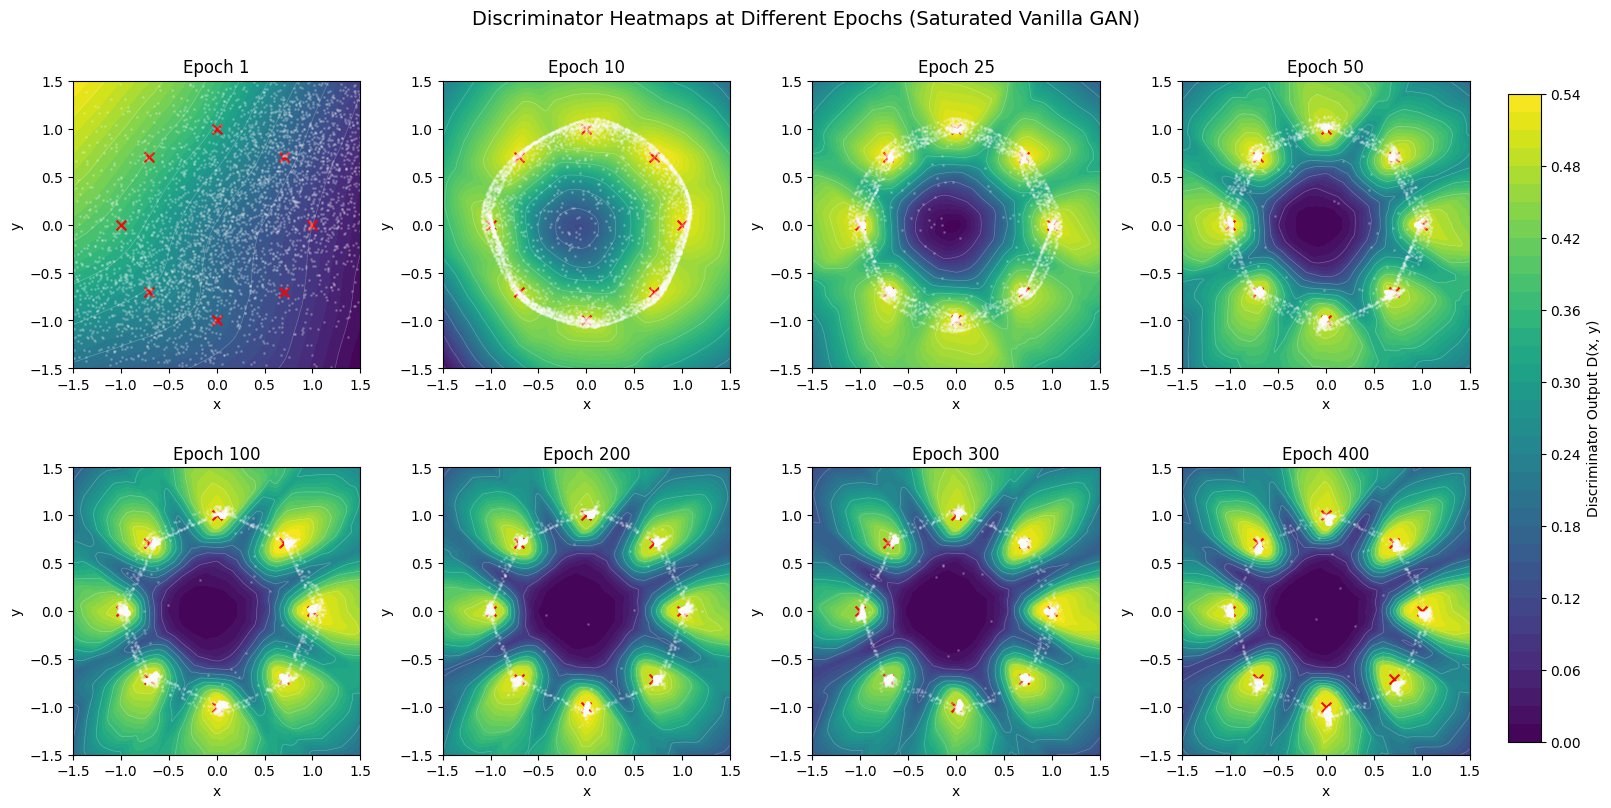

In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# =========================================================
# 2(b) Heatmap of Discriminator Outputs
# Improved layout version
# =========================================================

save_dir = "hw3_problem2a_saturated"
os.makedirs(save_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

heatmap_epochs = [1, 10, 25, 50, 100, 200, 300, 400]

# True mode centers
num_modes = 8
radius = 1.0
angles = np.linspace(0, 2 * np.pi, num_modes, endpoint=False)
means = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)

# Discriminator definition must match training
class Discriminator(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Grid for evaluating D(x, y)
x_min, x_max = -1.5, 1.5
y_min, y_max = -1.5, 1.5
grid_res = 250

x_vals = np.linspace(x_min, x_max, grid_res)
y_vals = np.linspace(y_min, y_max, grid_res)
xx, yy = np.meshgrid(x_vals, y_vals)

grid_points = np.stack([xx.ravel(), yy.ravel()], axis=1)
grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

# Better layout handling
fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
axes = axes.flatten()

last_im = None

for ax, ep in zip(axes, heatmap_epochs):
    d_path = os.path.join(save_dir, f"discriminator_epoch_{ep}.pth")

    D = Discriminator().to(device)
    D.load_state_dict(torch.load(d_path, map_location=device))
    D.eval()

    with torch.no_grad():
        d_out = D(grid_tensor).cpu().numpy().reshape(grid_res, grid_res)

    # Heatmap
    im = ax.contourf(xx, yy, d_out, levels=50, cmap="viridis")
    ax.contour(xx, yy, d_out, levels=8, colors="white", alpha=0.25, linewidths=0.5)

    # True centers
    ax.scatter(
        means[:, 0], means[:, 1],
        c="red", marker="x", s=50, linewidths=1.5, label="True Centers"
    )

    # Overlay generated samples saved from 2(a)
    gen_path = os.path.join(save_dir, f"generated_samples_epoch_{ep}.npy")
    if os.path.exists(gen_path):
        fake_samples = np.load(gen_path)
        ax.scatter(
            fake_samples[:, 0], fake_samples[:, 1],
            s=1.2, c="white", alpha=0.18, label="Generated Samples"
        )

    ax.set_title(f"Epoch {ep}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal")
    ax.grid(False)

    last_im = im

# Shared title
fig.suptitle("Discriminator Heatmaps at Different Epochs (Saturated Vanilla GAN)", fontsize=14)

# Better colorbar placement
cbar = fig.colorbar(last_im, ax=axes.tolist(), shrink=0.85, pad=0.02)
cbar.set_label("Discriminator Output D(x, y)")

# Save and show
plt.savefig(os.path.join(save_dir, "discriminator_heatmaps_all_epochs.png"), dpi=300, bbox_inches="tight")
plt.show()

Report 2(b)

To analyze the evolution of the discriminator, I tested the discriminator over a dense 2D grid over the input space and plotted the result as heatmaps at epochs 1, 10, 25, 50, 100, 200, 300, and 400. In each figure, the true mode centers and the generated samples from the corresponding epoch have been overlaid.

From the heatmaps, it is evident that there is a significant evolution in the behavior of the discriminator over the epochs:
	•	Epoch 1: The discriminator is not well-shaped around the ring.

	•	Epoch 10: The structure starts to appear, and the discriminator starts scoring differently over the manifold.

	•	Epochs 25-50: The discriminator has clearly picked up the structure and is forming a ring with higher responses over the mode locations and lower responses over the center.

	•	Epochs 100-400: The discriminator has stabilized and is clearly structured with repeated responses over the locations of the 8 modes and lower responses over the center.

  This behavior is consistent with successful training of the GAN on the ring dataset. The discriminator is effectively learning that data is concentrated near the 8 locations in the 8-mode distribution, but that areas such as the middle of the circle are less likely in the original data distribution.

**Code Adaptation / Clarification**

This portion of the code needed to be adapted beyond the basic training code:
	• Construction of a dense 2D grid for evaluation

	• Loading discriminator checkpoints from different epochs

	• Calculating discriminator outputs for all points in the grid
  
	• Plotting heatmaps of discriminator outputs with generated samples and true centers

These changes were made to satisfy the requirement for plotting discriminator outputs over time.

(c) [10 points] Compute Success and Failure Rates. Over 50 random seeds where you train a new model for
each seed, calculate:
• Success rate = % of runs where all 8 modes are covered.
• Failure rate = % of runs where 0 modes are covered.

In [32]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# =========================================================
# 2(c) Success and Failure Rates over 50 random seeds
# Saturated Vanilla GAN
# =========================================================

save_dir = "hw3_problem2c_saturated_multiseed"
os.makedirs(save_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Global settings
# -----------------------------
num_seeds = 50
seed_list = list(range(num_seeds))   # [0, 1, ..., 49]

num_samples = 50000
num_modes = 8
radius = 1.0
variance = 25e-4
std = np.sqrt(variance)

batch_size = 256
noise_dim = 2
hidden_dim = 128
lr = 1e-4
num_epochs = 400
eps = 1e-8

# Coverage threshold = 3 sigma = 3 * 0.05 = 0.15
coverage_threshold = 0.15

# Save static mode centers
angles = np.linspace(0, 2 * np.pi, num_modes, endpoint=False)
means = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)
np.save(os.path.join(save_dir, "ring_means.npy"), means)

# =========================================================
# Models
# =========================================================
class Generator(nn.Module):
    def __init__(self, noise_dim=2, hidden_dim=128, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# =========================================================
# Helpers
# =========================================================
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

def generate_ring_dataset(seed):
    """
    Generate the 8-mode Gaussian ring dataset for one seed.
    """
    rng = np.random.RandomState(seed)

    mode_indices = rng.choice(num_modes, size=num_samples)
    samples = means[mode_indices] + rng.randn(num_samples, 2) * std
    return samples

def compute_mode_coverage(generated_samples, mode_centers, threshold=0.15):
    covered = set()
    for sample in generated_samples:
        dists = np.linalg.norm(mode_centers - sample, axis=1)
        nearest = np.argmin(dists)
        if dists[nearest] <= threshold:
            covered.add(nearest)
    return len(covered), sorted(list(covered))

def train_one_saturated_run(seed):
    """
    Train one saturated vanilla GAN for one seed and return final coverage info.
    """
    set_all_seeds(seed)

    # Dataset for this seed
    samples = generate_ring_dataset(seed)
    data_tensor = torch.tensor(samples, dtype=torch.float32)
    dataset = TensorDataset(data_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    # Models
    G = Generator(noise_dim=noise_dim, hidden_dim=hidden_dim).to(device)
    D = Discriminator(input_dim=2, hidden_dim=hidden_dim).to(device)

    optimizer_G = optim.Adam(G.parameters(), lr=lr)
    optimizer_D = optim.Adam(D.parameters(), lr=lr)
    bce = nn.BCELoss()

    g_loss_history = []
    d_loss_history = []

    # Training loop
    for epoch in range(1, num_epochs + 1):
        G.train()
        D.train()

        epoch_g_loss = 0.0
        epoch_d_loss = 0.0
        num_batches = 0

        for (real_batch,) in dataloader:
            real_batch = real_batch.to(device)
            curr_batch_size = real_batch.size(0)

            real_labels = torch.ones(curr_batch_size, 1, device=device)
            fake_labels = torch.zeros(curr_batch_size, 1, device=device)

            # -------------------------
            # Train Discriminator
            # -------------------------
            optimizer_D.zero_grad()

            real_out = D(real_batch)
            d_loss_real = bce(real_out, real_labels)

            z = torch.randn(curr_batch_size, noise_dim, device=device)
            fake_batch = G(z)
            fake_out = D(fake_batch.detach())
            d_loss_fake = bce(fake_out, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optimizer_D.step()

            # -------------------------
            # Train Generator (saturated)
            # minimize log(1 - D(G(z)))
            # -------------------------
            optimizer_G.zero_grad()

            z = torch.randn(curr_batch_size, noise_dim, device=device)
            fake_batch = G(z)
            fake_out = D(fake_batch)

            g_loss_sat = torch.mean(torch.log(1.0 - fake_out + eps))
            g_loss_sat.backward()
            optimizer_G.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss_sat.item()
            num_batches += 1

        g_loss_history.append(epoch_g_loss / num_batches)
        d_loss_history.append(epoch_d_loss / num_batches)

    # Final coverage evaluation
    G.eval()
    with torch.no_grad():
        z_eval = torch.randn(5000, noise_dim, device=device)
        fake_eval = G(z_eval).cpu().numpy()

    final_coverage, covered_modes = compute_mode_coverage(
        fake_eval, means, threshold=coverage_threshold
    )

    result = {
        "seed": int(seed),
        "final_coverage": int(final_coverage),
        "covered_modes": covered_modes,
        "success": int(final_coverage == 8),
        "failure": int(final_coverage == 0),
        "final_g_loss": float(g_loss_history[-1]),
        "final_d_loss": float(d_loss_history[-1]),
    }

    # Save per-seed final samples for future reference
    np.save(
        os.path.join(save_dir, f"generated_samples_seed_{seed}.npy"),
        fake_eval
    )

    return result

# =========================================================
# Run all seeds
# =========================================================
all_results = []

for i, seed in enumerate(seed_list, start=1):
    result = train_one_saturated_run(seed)
    all_results.append(result)

    print(
        f"Seed {seed:02d} [{i}/{num_seeds}] | "
        f"Coverage: {result['final_coverage']}/8 | "
        f"Success: {result['success']} | Failure: {result['failure']}"
    )

# =========================================================
# Aggregate results
# =========================================================
final_coverages = [r["final_coverage"] for r in all_results]
num_success = sum(r["success"] for r in all_results)
num_failure = sum(r["failure"] for r in all_results)

success_rate = 100.0 * num_success / num_seeds
failure_rate = 100.0 * num_failure / num_seeds

summary = {
    "num_seeds": num_seeds,
    "success_count": int(num_success),
    "failure_count": int(num_failure),
    "success_rate_percent": float(success_rate),
    "failure_rate_percent": float(failure_rate),
    "coverage_threshold": float(coverage_threshold),
    "final_coverages": final_coverages,
    "unique_coverages": sorted(list(set(final_coverages))),
}

print("\n==================== 2(c) Summary ====================")
print(f"Success count  : {num_success}/{num_seeds}")
print(f"Failure count  : {num_failure}/{num_seeds}")
print(f"Success rate   : {success_rate:.2f}%")
print(f"Failure rate   : {failure_rate:.2f}%")
print(f"Unique coverages observed: {summary['unique_coverages']}")

# =========================================================
# Save results
# =========================================================
with open(os.path.join(save_dir, "multiseed_results.json"), "w") as f:
    json.dump(all_results, f, indent=2)

with open(os.path.join(save_dir, "multiseed_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

np.save(os.path.join(save_dir, "final_coverages.npy"), np.array(final_coverages))

# Save a simple CSV too
csv_path = os.path.join(save_dir, "multiseed_results.csv")
with open(csv_path, "w") as f:
    f.write("seed,final_coverage,success,failure,final_g_loss,final_d_loss\n")
    for r in all_results:
        f.write(
            f"{r['seed']},{r['final_coverage']},{r['success']},{r['failure']},"
            f"{r['final_g_loss']},{r['final_d_loss']}\n"
        )

# =========================================================
# Plot histogram of final coverage across seeds
# =========================================================
plt.figure(figsize=(8, 5))
bins = np.arange(-0.5, 9.5, 1.0)
plt.hist(final_coverages, bins=bins, edgecolor="black")
plt.xticks(range(0, 9))
plt.xlabel("Final Mode Coverage")
plt.ylabel("Number of Seeds")
plt.title("Distribution of Final Mode Coverage Over 50 Seeds\n(Saturated Vanilla GAN)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "coverage_histogram_50_seeds.png"), dpi=300)
plt.show()

# =========================================================
# Plot final coverage vs seed
# =========================================================
plt.figure(figsize=(9, 5))
plt.plot(seed_list, final_coverages, marker="o", linewidth=1.2)
plt.xlabel("Seed")
plt.ylabel("Final Mode Coverage")
plt.title("Final Mode Coverage vs Seed\n(Saturated Vanilla GAN)")
plt.ylim(-0.2, 8.2)
plt.yticks(range(0, 9))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "coverage_vs_seed_50_seeds.png"), dpi=300)
plt.show()

print("\nSaved files in:", save_dir)

Using device: cuda
Seed 00 [1/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed 01 [2/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed 02 [3/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed 03 [4/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed 04 [5/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed 05 [6/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed 06 [7/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed 07 [8/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed 08 [9/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed 09 [10/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed 10 [11/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed 11 [12/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed 12 [13/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed 13 [14/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed 14 [15/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed 15 [16/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed 16 [17/50] | Coverage: 8/8 | Success: 1 | Failure: 0
Seed

TypeError: Object of type int64 is not JSON serializable

In [35]:
with open(os.path.join(save_dir, "multiseed_results.json"), "w") as f:
    json.dump(all_results, f, indent=2, default=int)

with open(os.path.join(save_dir, "multiseed_summary.json"), "w") as f:
    json.dump(summary, f, indent=2, default=int)

np.save(
    os.path.join(save_dir, "final_coverages.npy"),
    np.array(final_coverages, dtype=np.int32)
)

csv_path = os.path.join(save_dir, "multiseed_results.csv")
with open(csv_path, "w") as f:
    f.write("seed,final_coverage,success,failure,final_g_loss,final_d_loss\n")
    for r in all_results:
        f.write(
            f"{int(r['seed'])},{int(r['final_coverage'])},{int(r['success'])},{int(r['failure'])},"
            f"{float(r['final_g_loss'])},{float(r['final_d_loss'])}\n"
        )

print("Saved files in:", save_dir)

Saved files in: hw3_problem2c_saturated_multiseed


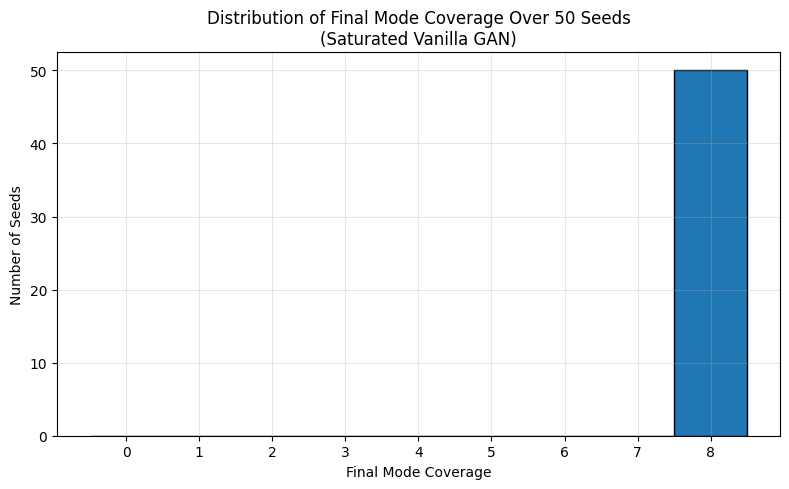

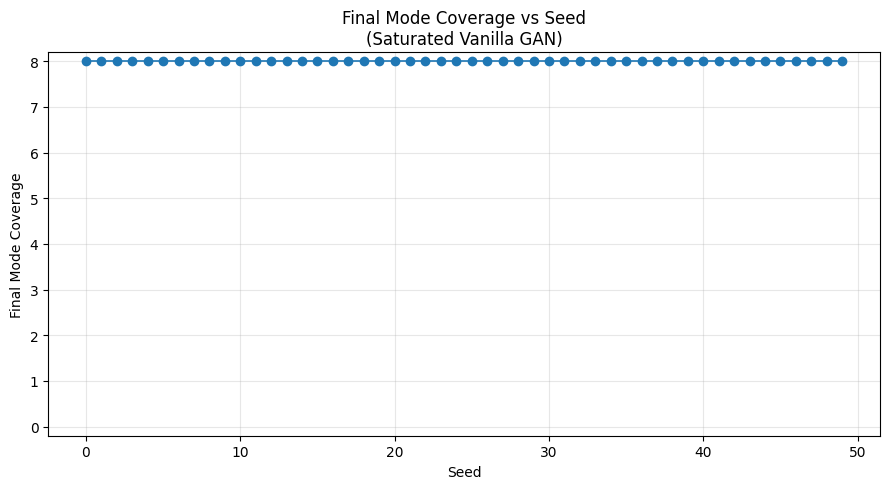

In [36]:
# =========================================================
# Plot histogram of final coverage across seeds
# =========================================================
plt.figure(figsize=(8, 5))
bins = np.arange(-0.5, 9.5, 1.0)
plt.hist(final_coverages, bins=bins, edgecolor="black")
plt.xticks(range(0, 9))
plt.xlabel("Final Mode Coverage")
plt.ylabel("Number of Seeds")
plt.title("Distribution of Final Mode Coverage Over 50 Seeds\n(Saturated Vanilla GAN)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "coverage_histogram_50_seeds.png"), dpi=300)
plt.show()

# =========================================================
# Plot final coverage vs seed
# =========================================================
plt.figure(figsize=(9, 5))
plt.plot(seed_list, final_coverages, marker="o", linewidth=1.2)
plt.xlabel("Seed")
plt.ylabel("Final Mode Coverage")
plt.title("Final Mode Coverage vs Seed\n(Saturated Vanilla GAN)")
plt.ylim(-0.2, 8.2)
plt.yticks(range(0, 9))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "coverage_vs_seed_50_seeds.png"), dpi=300)
plt.show()


In [37]:
num_success = sum(1 for c in final_coverages if c == 8)
num_failure = sum(1 for c in final_coverages if c == 0)

success_rate = 100 * num_success / len(final_coverages)
failure_rate = 100 * num_failure / len(final_coverages)

print(f"Success count: {num_success}/{len(final_coverages)}")
print(f"Failure count: {num_failure}/{len(final_coverages)}")
print(f"Success rate: {success_rate:.2f}%")
print(f"Failure rate: {failure_rate:.2f}%")

Success count: 50/50
Failure count: 0/50
Success rate: 100.00%
Failure rate: 0.00%


For this part, I used the saturated vanilla GAN with over 50 random seeds, with a new model and new dataset realization per random seed. After each random seed, the final mode coverage and whether the experiment was a success or failure were computed as follows:
	•	Success: All 8 modes were covered

	•	Failure: 0 modes were covered

The multi-seed experiment results indicated that all runs successfully covered all modes. The printed summary indicated that the results were as follows:
	•	Success count: 50 / 50

	•	Failure count: 0 / 50

	•	Success rate: 100.00%

	•	Failure rate: 0.00%

Additionally, the histogram of final mode coverage over the 50 random seeds indicated that the final mode coverage was consistently 8 over all runs, and the final-coverage-vs-seed plot indicated that the final coverage was consistently 8 over all random seeds.

The results indicate that the saturated vanilla GAN is quite reliable when using the 2D Gaussian ring dataset with the chosen parameters and implementation. At least with this experiment, the vanilla GAN did not show the usual instability and failure that is common when using vanilla GANs with difficult datasets.

To fulfill this section, the code has been changed significantly beyond the training script that runs once:
	•	A multi-seed training loop has been added

	•	Random seeds for numpy, pytorch, and cuda have been reset

	•	A new model has been trained with each set of random seeds

	•	The final mode coverage has been computed and stored for all runs

	•	Statistics have been accumulated over all runs

	•	Summary plots and csv/json outputs have been generated

The reason for these changes is that the code that runs the training once is not sufficient to obtain the success and failure rates. The multi-seed evaluation is crucial to evaluate the stability of the training statistically.

3. [10 points] Generate Samples from Trained Models. For the non-saturating (NS) vanilla GAN you are
considering, see if you can reproduce the results for this setting (i.e., NS vanilla GAN (αD = 1.0, αG = 1.0))
performance reported in Figure 3 by plotting generated samples from your trained GAN. IN other words, you
are to reproduce the top row of Figure 3 to obtain a scatter plot of samples as a function of the seed number
(you can randomly pick 6 seeds). Additionally, the second row of your plot will show such samples
for the saturating vanilla GAN setting which isn’t in the original paper. For both cases, please
note that the vanilla GAN is simply the setting of (αD = 1.0, αG = 1.0) and there is no need to
think about α at all for this homework!

Using device: cuda
NS Seed 00 [1/50] | G loss: 0.7233 | D loss: 1.3721
NS Seed 01 [2/50] | G loss: 0.7139 | D loss: 1.3765
NS Seed 02 [3/50] | G loss: 0.7250 | D loss: 1.3739
NS Seed 03 [4/50] | G loss: 0.7092 | D loss: 1.3774
NS Seed 04 [5/50] | G loss: 0.9273 | D loss: 1.2205
NS Seed 05 [6/50] | G loss: 0.9138 | D loss: 1.2297
NS Seed 06 [7/50] | G loss: 0.7374 | D loss: 1.3682
NS Seed 07 [8/50] | G loss: 0.7312 | D loss: 1.3711
NS Seed 08 [9/50] | G loss: 0.7117 | D loss: 1.3777
NS Seed 09 [10/50] | G loss: 0.7178 | D loss: 1.3753
NS Seed 10 [11/50] | G loss: 0.7078 | D loss: 1.3779
NS Seed 11 [12/50] | G loss: 0.7094 | D loss: 1.3759
NS Seed 12 [13/50] | G loss: 0.7142 | D loss: 1.3741
NS Seed 13 [14/50] | G loss: 0.7217 | D loss: 1.3771
NS Seed 14 [15/50] | G loss: 0.7224 | D loss: 1.3734
NS Seed 15 [16/50] | G loss: 0.8176 | D loss: 1.2956
NS Seed 16 [17/50] | G loss: 0.7076 | D loss: 1.3787
NS Seed 17 [18/50] | G loss: 0.7114 | D loss: 1.3765
NS Seed 18 [19/50] | G loss: 0.7194 

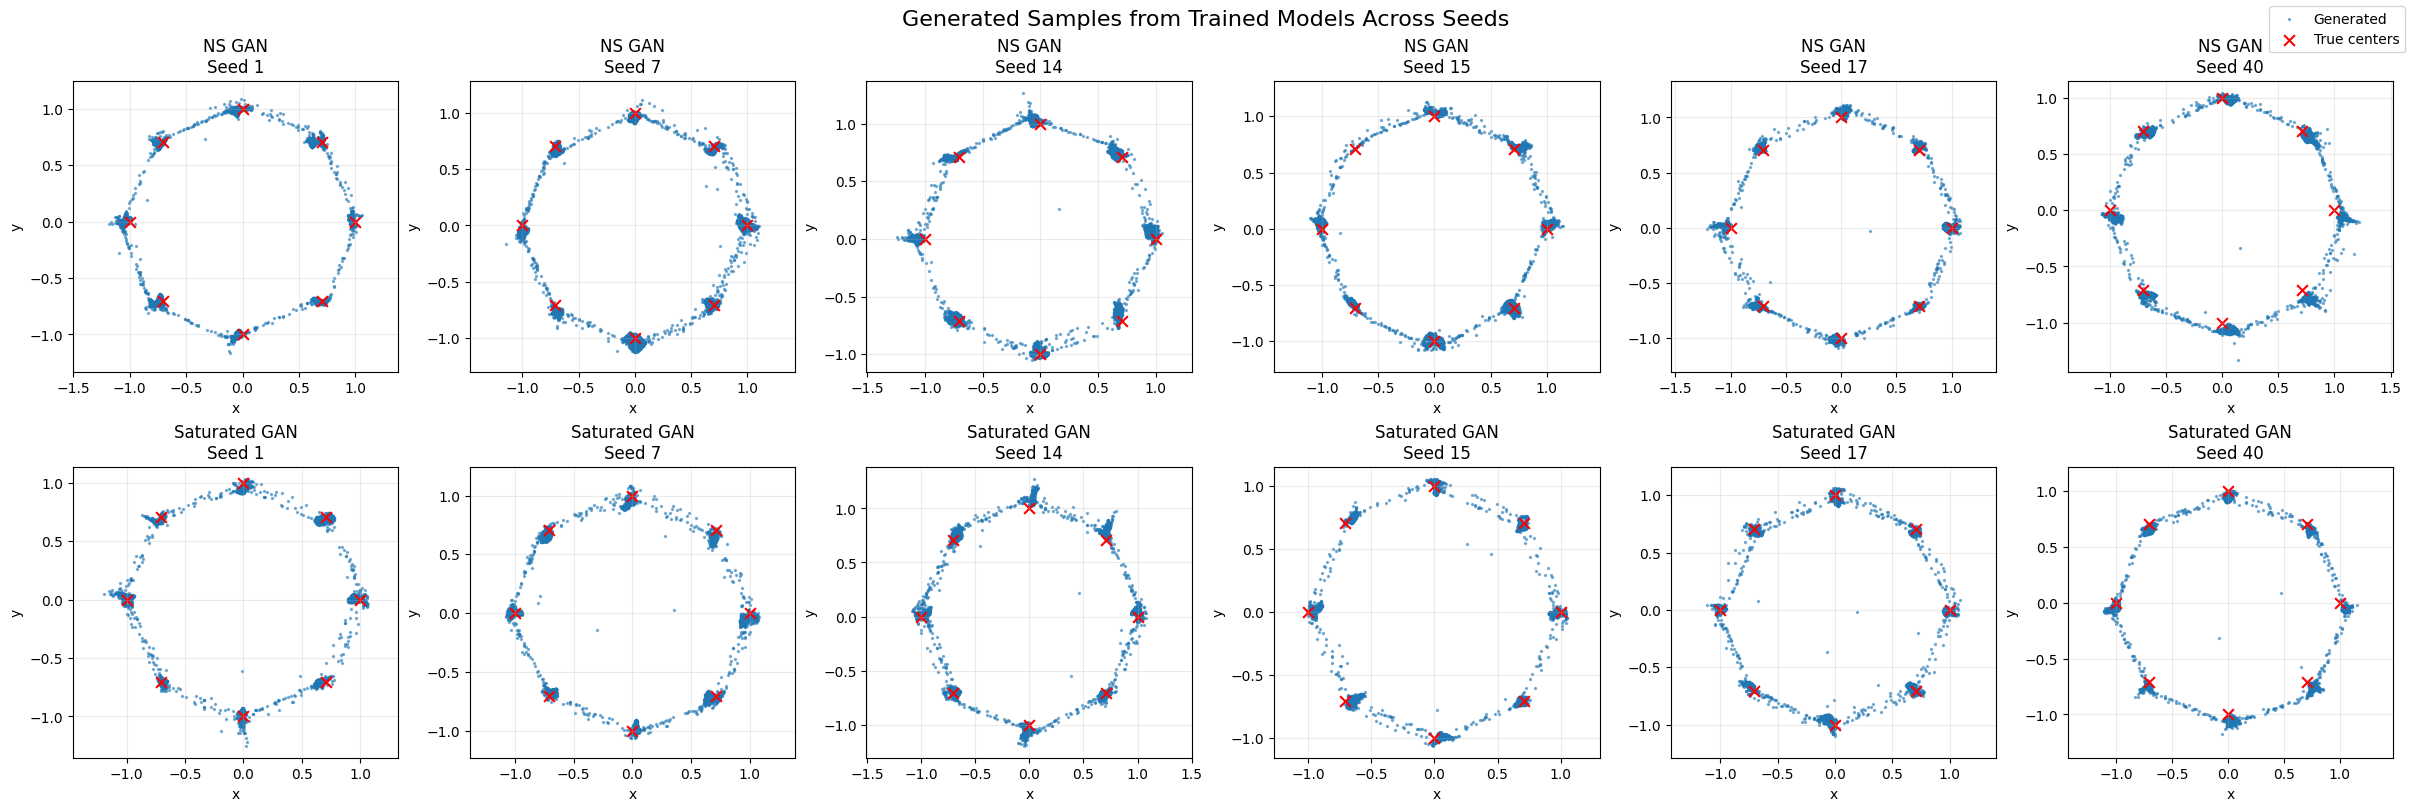


Saved files in: hw3_problem3_ns_multiseed


In [38]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# =========================================================
# 3. Generate Samples from Trained Models
# Top row    : Non-saturating vanilla GAN
# Bottom row : Saturating vanilla GAN
# =========================================================

# ---------------------------------------------------------
# Folders
# ---------------------------------------------------------
ns_save_dir = "hw3_problem3_ns_multiseed"
sat_save_dir = "hw3_problem2c_saturated_multiseed"   # from your 2(c)
os.makedirs(ns_save_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------------------------------------
# Global settings
# ---------------------------------------------------------
num_total_seeds = 50
seed_list = list(range(num_total_seeds))

num_samples = 50000
num_modes = 8
radius = 1.0
variance = 25e-4
std = np.sqrt(variance)

batch_size = 256
noise_dim = 2
hidden_dim = 128
lr = 1e-4
num_epochs = 400
eps = 1e-8

# ---------------------------------------------------------
# True mode centers
# ---------------------------------------------------------
angles = np.linspace(0, 2 * np.pi, num_modes, endpoint=False)
means = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)

np.save(os.path.join(ns_save_dir, "ring_means.npy"), means)

# =========================================================
# Models
# =========================================================
class Generator(nn.Module):
    def __init__(self, noise_dim=2, hidden_dim=128, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# =========================================================
# Helpers
# =========================================================
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

def generate_ring_dataset(seed):
    rng = np.random.RandomState(seed)
    mode_indices = rng.choice(num_modes, size=num_samples)
    samples = means[mode_indices] + rng.randn(num_samples, 2) * std
    return samples

def to_py(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

# =========================================================
# Train one Non-Saturating GAN run
# =========================================================
def train_one_ns_run(seed):
    set_all_seeds(seed)

    # Dataset for this seed
    samples = generate_ring_dataset(seed)
    data_tensor = torch.tensor(samples, dtype=torch.float32)
    dataset = TensorDataset(data_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    # Models
    G = Generator(noise_dim=noise_dim, hidden_dim=hidden_dim).to(device)
    D = Discriminator(input_dim=2, hidden_dim=hidden_dim).to(device)

    optimizer_G = optim.Adam(G.parameters(), lr=lr)
    optimizer_D = optim.Adam(D.parameters(), lr=lr)
    bce = nn.BCELoss()

    g_loss_history = []
    d_loss_history = []

    # Training loop
    for epoch in range(1, num_epochs + 1):
        G.train()
        D.train()

        epoch_g_loss = 0.0
        epoch_d_loss = 0.0
        num_batches = 0

        for (real_batch,) in dataloader:
            real_batch = real_batch.to(device)
            curr_batch_size = real_batch.size(0)

            real_labels = torch.ones(curr_batch_size, 1, device=device)
            fake_labels = torch.zeros(curr_batch_size, 1, device=device)

            # ---------------------------------
            # Train Discriminator
            # ---------------------------------
            optimizer_D.zero_grad()

            real_out = D(real_batch)
            d_loss_real = bce(real_out, real_labels)

            z = torch.randn(curr_batch_size, noise_dim, device=device)
            fake_batch = G(z)
            fake_out = D(fake_batch.detach())
            d_loss_fake = bce(fake_out, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optimizer_D.step()

            # ---------------------------------
            # Train Generator (NON-SATURATING)
            # minimize -log(D(G(z)))
            # with BCELoss + target 1
            # ---------------------------------
            optimizer_G.zero_grad()

            z = torch.randn(curr_batch_size, noise_dim, device=device)
            fake_batch = G(z)
            fake_out = D(fake_batch)

            g_loss_ns = bce(fake_out, real_labels)
            g_loss_ns.backward()
            optimizer_G.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss_ns.item()
            num_batches += 1

        g_loss_history.append(float(epoch_g_loss / num_batches))
        d_loss_history.append(float(epoch_d_loss / num_batches))

    # Final generated samples
    G.eval()
    with torch.no_grad():
        z_eval = torch.randn(5000, noise_dim, device=device)
        fake_eval = G(z_eval).cpu().numpy()

    result = {
        "seed": int(seed),
        "final_g_loss": float(g_loss_history[-1]),
        "final_d_loss": float(d_loss_history[-1]),
    }

    # Save final generated samples for this seed
    np.save(os.path.join(ns_save_dir, f"generated_samples_seed_{seed}.npy"), fake_eval)

    return result

# =========================================================
# Run NS GAN over seeds
# =========================================================
ns_results = []

for i, seed in enumerate(seed_list, start=1):
    result = train_one_ns_run(seed)
    ns_results.append(result)

    print(
        f"NS Seed {seed:02d} [{i}/{num_total_seeds}] | "
        f"G loss: {result['final_g_loss']:.4f} | "
        f"D loss: {result['final_d_loss']:.4f}"
    )

# Save NS summary
ns_results_clean = [{k: to_py(v) for k, v in r.items()} for r in ns_results]

with open(os.path.join(ns_save_dir, "ns_multiseed_results.json"), "w") as f:
    json.dump(ns_results_clean, f, indent=2)

# =========================================================
# Pick 6 seeds for plotting
# =========================================================
random.seed(42)
picked_seeds = sorted(random.sample(seed_list, 6))
print("Picked seeds for figure:", picked_seeds)

with open(os.path.join(ns_save_dir, "picked_seeds_problem3.json"), "w") as f:
    json.dump({"picked_seeds": picked_seeds}, f, indent=2)

# =========================================================
# Plot comparison figure
# Top row    : NS vanilla GAN
# Bottom row : Saturating vanilla GAN
# =========================================================
fig, axes = plt.subplots(2, 6, figsize=(24, 8), constrained_layout=True)

for col, seed in enumerate(picked_seeds):
    # -------------------------
    # Top row: NS vanilla GAN
    # -------------------------
    ax_top = axes[0, col]
    ns_path = os.path.join(ns_save_dir, f"generated_samples_seed_{seed}.npy")
    ns_samples = np.load(ns_path)

    ax_top.scatter(ns_samples[:, 0], ns_samples[:, 1], s=2, alpha=0.5, label="Generated")
    ax_top.scatter(means[:, 0], means[:, 1], c="red", marker="x", s=60, linewidths=1.5, label="True centers")
    ax_top.set_title(f"NS GAN\nSeed {seed}")
    ax_top.set_xlabel("x")
    ax_top.set_ylabel("y")
    ax_top.axis("equal")
    ax_top.grid(True, alpha=0.25)

    # -------------------------
    # Bottom row: Saturating GAN
    # -------------------------
    ax_bottom = axes[1, col]
    sat_path = os.path.join(sat_save_dir, f"generated_samples_seed_{seed}.npy")

    if os.path.exists(sat_path):
        sat_samples = np.load(sat_path)
        ax_bottom.scatter(sat_samples[:, 0], sat_samples[:, 1], s=2, alpha=0.5, label="Generated")
        ax_bottom.scatter(means[:, 0], means[:, 1], c="red", marker="x", s=60, linewidths=1.5, label="True centers")
        ax_bottom.set_title(f"Saturated GAN\nSeed {seed}")
    else:
        ax_bottom.text(0.5, 0.5, f"Missing samples\nSeed {seed}", ha="center", va="center", transform=ax_bottom.transAxes)
        ax_bottom.set_title(f"Saturated GAN\nSeed {seed}")

    ax_bottom.set_xlabel("x")
    ax_bottom.set_ylabel("y")
    ax_bottom.axis("equal")
    ax_bottom.grid(True, alpha=0.25)

fig.suptitle("Generated Samples from Trained Models Across Seeds", fontsize=16)

# shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.savefig(os.path.join(ns_save_dir, "problem3_ns_vs_saturated_6seeds.png"), dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved files in:", ns_save_dir)